In [ ]:
!pip install kaggle


In [ ]:
import os
import shutil

os.makedirs('/root/.kaggle', exist_ok=True)
shutil.copy('kaggle.json', '/root/.kaggle/kaggle.json')

os.chmod('/root/.kaggle/kaggle.json', 600)

In [ ]:
!kaggle datasets download -d anthonytherrien/dog-vs-cat

Dataset URL: https://www.kaggle.com/datasets/anthonytherrien/dog-vs-cat
License(s): CC-BY-SA-4.0
100% 360M/360M [00:05<00:00, 63.9MB/s]



In [ ]:
!unzip dog-vs-cat.zip

Archive:  dog-vs-cat.zip
  inflating: animals/cat/00000-4122619873.png  
  inflating: animals/cat/00001-4122619874.png  
  inflating: animals/cat/00002-4122619875.png  
  inflating: animals/cat/00003-4122619876.png  
  inflating: animals/cat/00004-4122619877.png  
  inflating: animals/cat/00005-4122619878.png  
  inflating: animals/cat/00006-4122619879.png  
  inflating: animals/cat/00007-4122619880.png  
  inflating: animals/cat/00008-4122619881.png  
  inflating: animals/cat/00009-4122619882.png  
  inflating: animals/cat/00010-4122619883.png  
  inflating: animals/cat/00011-4122619884.png  
  inflating: animals/cat/00012-4122619885.png  
  inflating: animals/cat/00013-4122619886.png  
  inflating: animals/cat/00014-4122619887.png  
  inflating: animals/cat/00015-4122619888.png  
  inflating: animals/cat/00016-4122619889.png  
  inflating: animals/cat/00017-4122619890.png  
  inflating: animals/cat/00018-4122619891.png  
  inflating: animals/cat/00019-4122619892.png  
  inflating: an

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os
import tqdm
import random
from keras.preprocessing.image import load_img
warnings.filterwarnings('ignore')

In [ ]:
import os

input_path = []
label = []

dataset_path = "animals"

for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        input_path.append(img_path)

        if class_name.lower() == 'cat':
            label.append(0)
        else:
            label.append(1)

print(input_path[0], label[0])
print("Total images:", len(input_path))

animals/cat/00168-200124478.png 0
Total images: 1000


In [ ]:
import pandas as pd

df = pd.DataFrame({
    'image': input_path,
    'label': label
})

print(df.head())

                             image  label
0  animals/cat/00168-200124478.png      0
1  animals/cat/00220-200124530.png      0
2  animals/cat/00383-200124693.png      0
3  animals/cat/00236-200124546.png      0
4  animals/cat/00248-200124558.png      0


In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

print("Train:", len(train_df))
print("Test:", len(test_df))

Train: 800
Test: 200


In [ ]:
from keras.preprocessing.image import img_to_array, load_img
import numpy as np

IMG_SIZE = 128

def process_image(path):
    img = load_img(path, target_size=(IMG_SIZE, IMG_SIZE))
    img = img_to_array(img) / 255.0
    return img

X_train = np.array([process_image(p) for p in train_df['image']])
y_train = np.array(train_df['label'])

X_test = np.array([process_image(p) for p in test_df['image']])
y_test = np.array(test_df['label'])

print(X_train.shape)

(800, 128, 128, 3)


In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_test, y_test)
)


Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.5688 - loss: 0.7037 - val_accuracy: 0.7800 - val_loss: 0.5654
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.8000 - loss: 0.4328 - val_accuracy: 0.8750 - val_loss: 0.3171
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 38s 975ms/step - accuracy: 0.8913 - loss: 0.2696 - val_accuracy: 0.9000 - val_loss: 0.2219
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 41s 997ms/step - accuracy: 0.9125 - loss: 0.2004 - val_accuracy: 0.9300 - val_loss: 0.1852
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 24s 946ms/step - accuracy: 0.9613 - loss: 0.1141 - val_accuracy: 0.9350 - val_loss: 0.1726
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.9787 - loss: 0.0745 - val_accuracy: 0.9550 - val_loss: 0.1341
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.9900 - loss: 0.0409 - val_accuracy: 0.9550 - val_loss: 0.1379
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9987 - loss: 0.0143 - val_accuracy: 0.9750 - 

In [ ]:
loss, acc = model.evaluate(X_test, y_test)
print("Accuracy:", acc)

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 388ms/step - accuracy: 0.9850 - loss: 0.0814
Accuracy: 0.9850000143051147


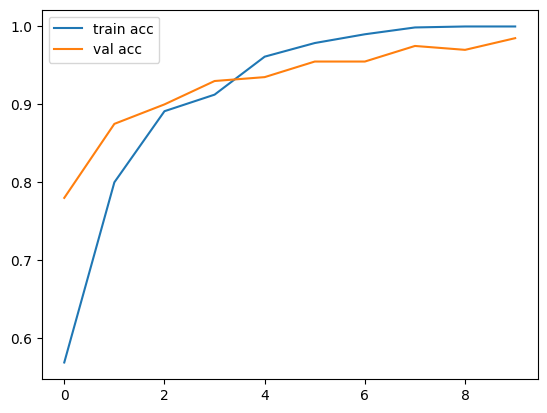

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()

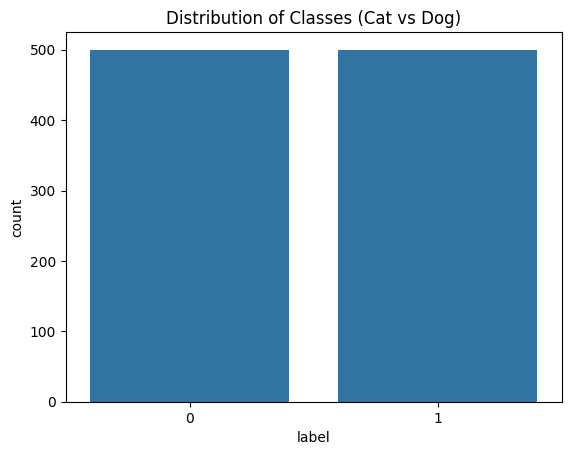

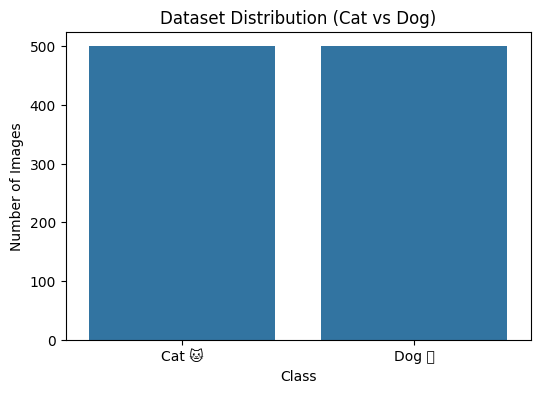

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

ax = sns.countplot(x='label', data=df)

# Labels convert
ax.set_xticklabels(['Cat 🐱', 'Dog 🐶'])

# Count values show on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + 0.3, p.get_height() + 50))

plt.title("Dataset Distribution (Cat vs Dog)")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()